In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from scipy.optimize import curve_fit

/home/ivan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
def sigmodal_response( X, EC50, HS, Bot, Top):
    return ((Top - Bot)/(1 + ((X/EC50)**HS))) + Bot

In [5]:
plate_num = pd.read_csv('K562_WYT_DR240417_Assay662_666_CellOrder.csv')
raw_data = pd.read_csv('K562_WYT_DR240417_Assay662_666_Data.csv')
drug_map = pd.read_csv('K562_WYT_DR240417_Assay662_666_PlateMap.csv')
data_plate = pd.merge(plate_num, raw_data, on='PlateNumber')
data = pd.merge(data_plate, drug_map, on=['PlateMap', 'Well'])

In [6]:
data

,PlateNumber,Cell,sgRNA,PlateMap,Well,Signal,Drug,Conc
0,1,WT,BCR2_1054,A,B02,25408,asciminib,2000.000000
1,1,WT,BCR2_1054,A,B03,26100,asciminib,1000.000000
2,1,WT,BCR2_1054,A,B04,58040,asciminib,125.000000
3,1,WT,BCR2_1054,A,B05,151632,asciminib,50.000000
4,1,WT,BCR2_1054,A,B06,340636,asciminib,30.000000
...,...,...,...,...,...,...,...,...
2515,42,T315I,AAVS1,B,G07,2133608,trametinib,6.324555
2516,42,T315I,AAVS1,B,G08,2135348,trametinib,2.000000
2517,42,T315I,AAVS1,B,G09,2123264,trametinib,0.632456
2518,42,T315I,AAVS1,B,G10,2073216,trametinib,0.200000


In [7]:
sigmoid_para = []
sigmoid_fits = []
sigmoid_var = []

data['Norm'] = 1.0
for plate in data['PlateNumber'].drop_duplicates():
    DMSO_signal = data.loc[(data['PlateNumber']==plate) & (data['Conc']==0), 'Signal'].mean()
    data.loc[(data['PlateNumber']==plate), 'Norm'] = data.loc[(data['PlateNumber']==plate), 'Signal'] / DMSO_signal
    for drug in data.loc[data['PlateNumber']==plate, 'Drug'].drop_duplicates():
        data_drug = data.loc[(data['PlateNumber']==plate) & (data['Drug']==drug)]
        cell = data_drug['Cell'].drop_duplicates().values[0]
        sgRNA = data_drug['sgRNA'].drop_duplicates().values[0]
        data_drug = data_drug[['Conc', 'Norm']].groupby('Conc').mean().reset_index()
        popt, pcov = curve_fit(sigmodal_response, data_drug['Conc'], data_drug['Norm'], 
                               p0=(data_drug['Conc'].median(), 1, 0, 1),
                               bounds=((0 ,0,0,0.5),(data_drug['Conc'].max()*2,5,0.8,1.5)))
        conc_space = np.logspace(np.log10(data_drug['Conc'].nsmallest(2).iloc[-1]), np.log10(data_drug['Conc'].max()), 200)
        fit_line = sigmodal_response(conc_space, *popt)
        sigmoid_para.append([cell, sgRNA, drug, *popt])
        sigmoid_var.append([cell, sgRNA, drug, *np.sqrt(np.diag(pcov))])
        for i in range(len(conc_space)):
            sigmoid_fits.append([cell, sgRNA, drug, conc_space[i], fit_line[i]])

In [8]:
parameter_DF = pd.DataFrame(sigmoid_para, columns=['Cell', 'sgRNA','Drug', 'EC50', 'HS', 'Bot', 'Top']).round(3)
var_DF = pd.DataFrame(sigmoid_var, columns=['Cell', 'sgRNA','Drug', 'EC50', 'HS', 'Bot', 'Top']).round(5)
fit_DF = pd.DataFrame(sigmoid_fits, columns=['Cell', 'sgRNA','Drug', 'Conc', 'Responce'])

In [9]:
follow_edits = {'BCR2_909':'ABL E505G', 'BCRABL_1886':'ABL D325G','BCRABL_1928':'ABL M351V',
                'BCR2_1054':'ABL V73A', 'BCR2_1057':'ABL Y139H', 'CR1308':'BRAF K601E', 'AAVS1':'AAVS1'}

In [10]:
parameter_DF['Edit'] = parameter_DF['sgRNA'].map(follow_edits)

In [11]:
pd.pivot_table(parameter_DF, index=['Cell', 'sgRNA'], columns='Drug', values=['EC50'])

EC50                                
Drug              asciminib   imatinib ponatinib trametinib
Cell  sgRNA                                                
T315I AAVS1          29.882   4421.307     0.714    142.923
      BCR2_1054      32.616   1623.607     0.651    286.473
      BCR2_1057      74.516   4033.071     0.629    121.883
      BCR2_909      267.343   1107.229     0.663    103.583
      BCRABL_1886    37.396   1268.481     0.653     57.548
      BCRABL_1928    24.594   1960.966     0.660     85.112
      CR1308         51.111  11572.627     1.051    186.154
WT    AAVS1           4.153     95.223     0.181   1963.657
      BCR2_1054       9.951    109.142     0.157    120.735
      BCR2_1057      24.451    103.608     0.165   2186.111
      BCR2_909      264.414    114.482     0.201   1918.124
      BCRABL_1886    10.278    138.043     0.165   1782.531
      BCRABL_1928     5.661    197.124     0.179   1989.219
      CR1308          8.891    156.371     0.205   1318.665
Y253H AAVS1          13.901   4890.976     0.581    213.266
      BCR2_1054      31.647   6841.680     0.651    161.926
      BCR2_1057      43.292   5297.603     0.560    129.722
      BCR2_909      203.377   7196.393     0.646    105.548
      BCRABL_1886    38.620   5426.043     0.622    118.911
      BCRABL_1928    19.983   7747.345     0.635    103.705
      CR1308         25.748   9453.083     0.704    397.671

In [12]:
pd.pivot_table(var_DF, index=['Cell', 'sgRNA'], columns='Drug', values=['Bot'])

Bot                              
Drug              asciminib imatinib ponatinib trametinib
Cell  sgRNA                                              
T315I AAVS1         0.01639  0.41314   0.01880    0.08494
      BCR2_1054     0.01623  0.19481   0.01480    0.15879
      BCR2_1057     0.02966  0.30912   0.00961    0.06708
      BCR2_909      0.06951  0.08530   0.01007    0.05993
      BCRABL_1886   0.02033  0.19621   0.01700    0.03688
      BCRABL_1928   0.02051  0.36490   0.00998    0.05657
      CR1308        0.02845  0.59488   0.03405    0.07107
WT    AAVS1         0.01258  0.01054   0.01568    0.84824
      BCR2_1054     0.01971  0.02950   0.01892    0.06479
      BCR2_1057     0.00800  0.00746   0.01151    1.77870
      BCR2_909      0.09223  0.01286   0.01385    1.22803
      BCRABL_1886   0.01001  0.03609   0.01074    2.54858
      BCRABL_1928   0.01531  0.03381   0.00518    2.27066
      CR1308        0.01242  0.02434   0.02770    1.37035
Y253H AAVS1         0.01663  0.36168   0.01925    0.14169
      BCR2_1054     0.02322  0.67009   0.01128    0.10739
      BCR2_1057     0.01828  0.83833   0.01756    0.04899
      BCR2_909      0.10563  1.57597   0.01861    0.11688
      BCRABL_1886   0.02828  0.57852   0.02540    0.03405
      BCRABL_1928   0.01710  0.64142   0.02665    0.04926
      CR1308        0.01224  1.49959   0.01087    0.19859

In [13]:
data['Norm'] = data['Norm']*100
fit_DF['Responce'] = fit_DF['Responce']*100

In [14]:
follow_edits = {'BCR2_909':'ABL E505G', 'BCRABL_1886':'ABL D325G','BCRABL_1928':'ABL M351V',
                'BCR2_1054':'V73A', 'BCR2_1057':'ABL Y139H', 'CR1308':'BRAF K601E', 'AAVS1':'AAVS1'}

In [15]:
data['Guide'] = data['sgRNA'].map(follow_edits)
#mean_data['Guide'] = mean_data['sgRNA'].map(follow_edits)
fit_DF['Guide'] = fit_DF['sgRNA'].map(follow_edits)

Asc_data = data.loc[(data['Cell']!='T315I') & (data['Drug']=='asciminib') & (data['sgRNA'].isin(['AAVS1', 'BCR2_1054']))].sort_values(['sgRNA', 'Cell'])
Asc_data['K562'] = Asc_data['Cell'] 
Asc_fit = fit_DF.loc[(fit_DF['Cell']!='T315I') & (fit_DF['Drug']=='asciminib') & (fit_DF['sgRNA'].isin(['AAVS1', 'BCR2_1054']))].sort_values(['sgRNA', 'Cell'])
Asc_fit['K562'] = Asc_fit['Cell'] 

In [16]:
#sns.set_context('talk')
sns.set_context('notebook')
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'

In [17]:
Asc_data

,PlateNumber,Cell,sgRNA,PlateMap,Well,Signal,Drug,Conc,Norm,Guide,K562
360,7,WT,AAVS1,A,B02,26388,asciminib,2000.00,1.257108,AAVS1,WT
361,7,WT,AAVS1,A,B03,22560,asciminib,1000.00,1.074744,AAVS1,WT
362,7,WT,AAVS1,A,B04,28304,asciminib,125.00,1.348385,AAVS1,WT
363,7,WT,AAVS1,A,B05,54716,asciminib,50.00,2.606636,AAVS1,WT
364,7,WT,AAVS1,A,B06,110956,asciminib,30.00,5.285874,AAVS1,WT
...,...,...,...,...,...,...,...,...,...,...,...
445,8,Y253H,BCR2_1054,A,D07,1576624,asciminib,15.00,77.118576,V73A,Y253H
446,8,Y253H,BCR2_1054,A,D08,1891952,asciminib,7.50,92.542448,V73A,Y253H
447,8,Y253H,BCR2_1054,A,D09,1831760,asciminib,3.75,89.598232,V73A,Y253H
448,8,Y253H,BCR2_1054,A,D10,2001312,asciminib,1.00,97.891655,V73A,Y253H


In [18]:
Asc_fit['Context + Guide'] = Asc_fit['K562'] + ' + ' + Asc_fit['Guide']
Asc_data['Context + Guide'] = Asc_data['K562'] + ' + ' + Asc_data['Guide']
Asc_fit = Asc_fit.sort_values('Context + Guide')
Asc_data = Asc_data.sort_values('Context + Guide')

In [19]:
sns.set_context('talk')
mpl.rcParams['figure.figsize'] =6,5

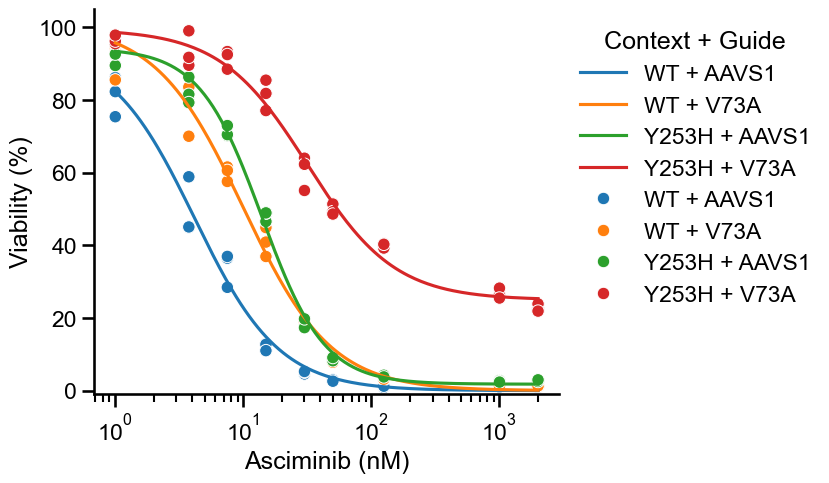

In [20]:
mpl.rcParams['figure.figsize'] =6,5
drug_resp = sns.lineplot(x='Conc', y='Responce', hue='Context + Guide', data=Asc_fit)
drug_resp = sns.scatterplot(x='Conc', y='Norm', hue='Context + Guide', markers='o', data=Asc_data)

drug_resp.set(xscale="log", ylabel='Viability (%)', xlabel= 'Asciminib (nM)', ylim=[-1, 105])
drug_resp.legend( frameon=False, bbox_to_anchor=(1, 1), title='Context + Guide')
sns.despine()
drug_resp.get_figure().savefig("/home/ivan/Desktop/Epi Analysis/Epistatic Confirmation/K562 WT and Y253H V73A Edited DR240417_talk.pdf" , dpi=1200,  transparent=True, bbox_inches='tight')

### Calculating the theoretical null model episatic effect

In [21]:
WT_f = Asc_fit.loc[(Asc_fit['Cell']=='WT')& (Asc_fit['Guide']=='AAVS1')].sort_values('Conc')['Responce'].values
VA_f = Asc_fit.loc[(Asc_fit['Cell']=='WT')& (Asc_fit['Guide']=='V73A')].sort_values('Conc')['Responce'].values
YH_f = Asc_fit.loc[(Asc_fit['Cell']=='Y253H')& (Asc_fit['Guide']=='AAVS1')].sort_values('Conc')['Responce'].values

WT_para = parameter_DF.loc[(parameter_DF['Drug']=='asciminib') & (parameter_DF['Cell']=='WT') & (parameter_DF['sgRNA']=='AAVS1'), ['EC50', 'HS','Bot','Top']].values
VA_para = parameter_DF.loc[(parameter_DF['Drug']=='asciminib') & (parameter_DF['Cell']=='WT') & (parameter_DF['sgRNA']=='BCR2_1054'), ['EC50', 'HS','Bot','Top']].values
YH_para = parameter_DF.loc[(parameter_DF['Drug']=='asciminib') & (parameter_DF['Cell']=='Y253H') & (parameter_DF['sgRNA']=='AAVS1'), ['EC50', 'HS','Bot','Top']].values

def dose_from_viability(v, para):
    EC50, HS, Bot, Top = para
    """
    Invert the 4PL curve: given viability v, return dose x.
    v, Bot, Top should be in same units (e.g. fraction 0–1).
    """
    eps = 0
    v = np.clip(v, Bot + eps, Top - eps)

    term = (Top - Bot) / (v - Bot) - 1.0
    x = EC50 * (term ** (1.0 / HS))
    return x

v_grid = np.linspace(0.001, 0.999, 2000)

C_WT = dose_from_viability(v_grid, WT_para[0])
C_A = dose_from_viability(v_grid, VA_para[0])
C_B = dose_from_viability(v_grid, YH_para[0])

def mani_expected_concentration(C_WT, C_A, C_B, min_wt=1e-9):
    C_WT = np.asarray(C_WT)
    C_A  = np.asarray(C_A)
    C_B  = np.asarray(C_B)

    C_exp = np.full_like(C_WT, np.nan, dtype=float)
    mask = C_WT > min_wt
    C_exp[mask] = (C_A[mask] * C_B[mask]) / C_WT[mask]
    return C_exp

C_AB_exp = mani_expected_concentration(C_WT, C_A, C_B)

/tmp/ipykernel_402919/948983865.py:18: RuntimeWarning: divide by zero encountered in divide
  term = (Top - Bot) / (v - Bot) - 1.0


In [22]:
sns.color_palette("colorblind")

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [23]:
sns.set_context('paper')

In [24]:
plt.rcParams.update({
    'figure.dpi': 600,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'axes.linewidth': 1,
    'pdf.fonttype': 42
})

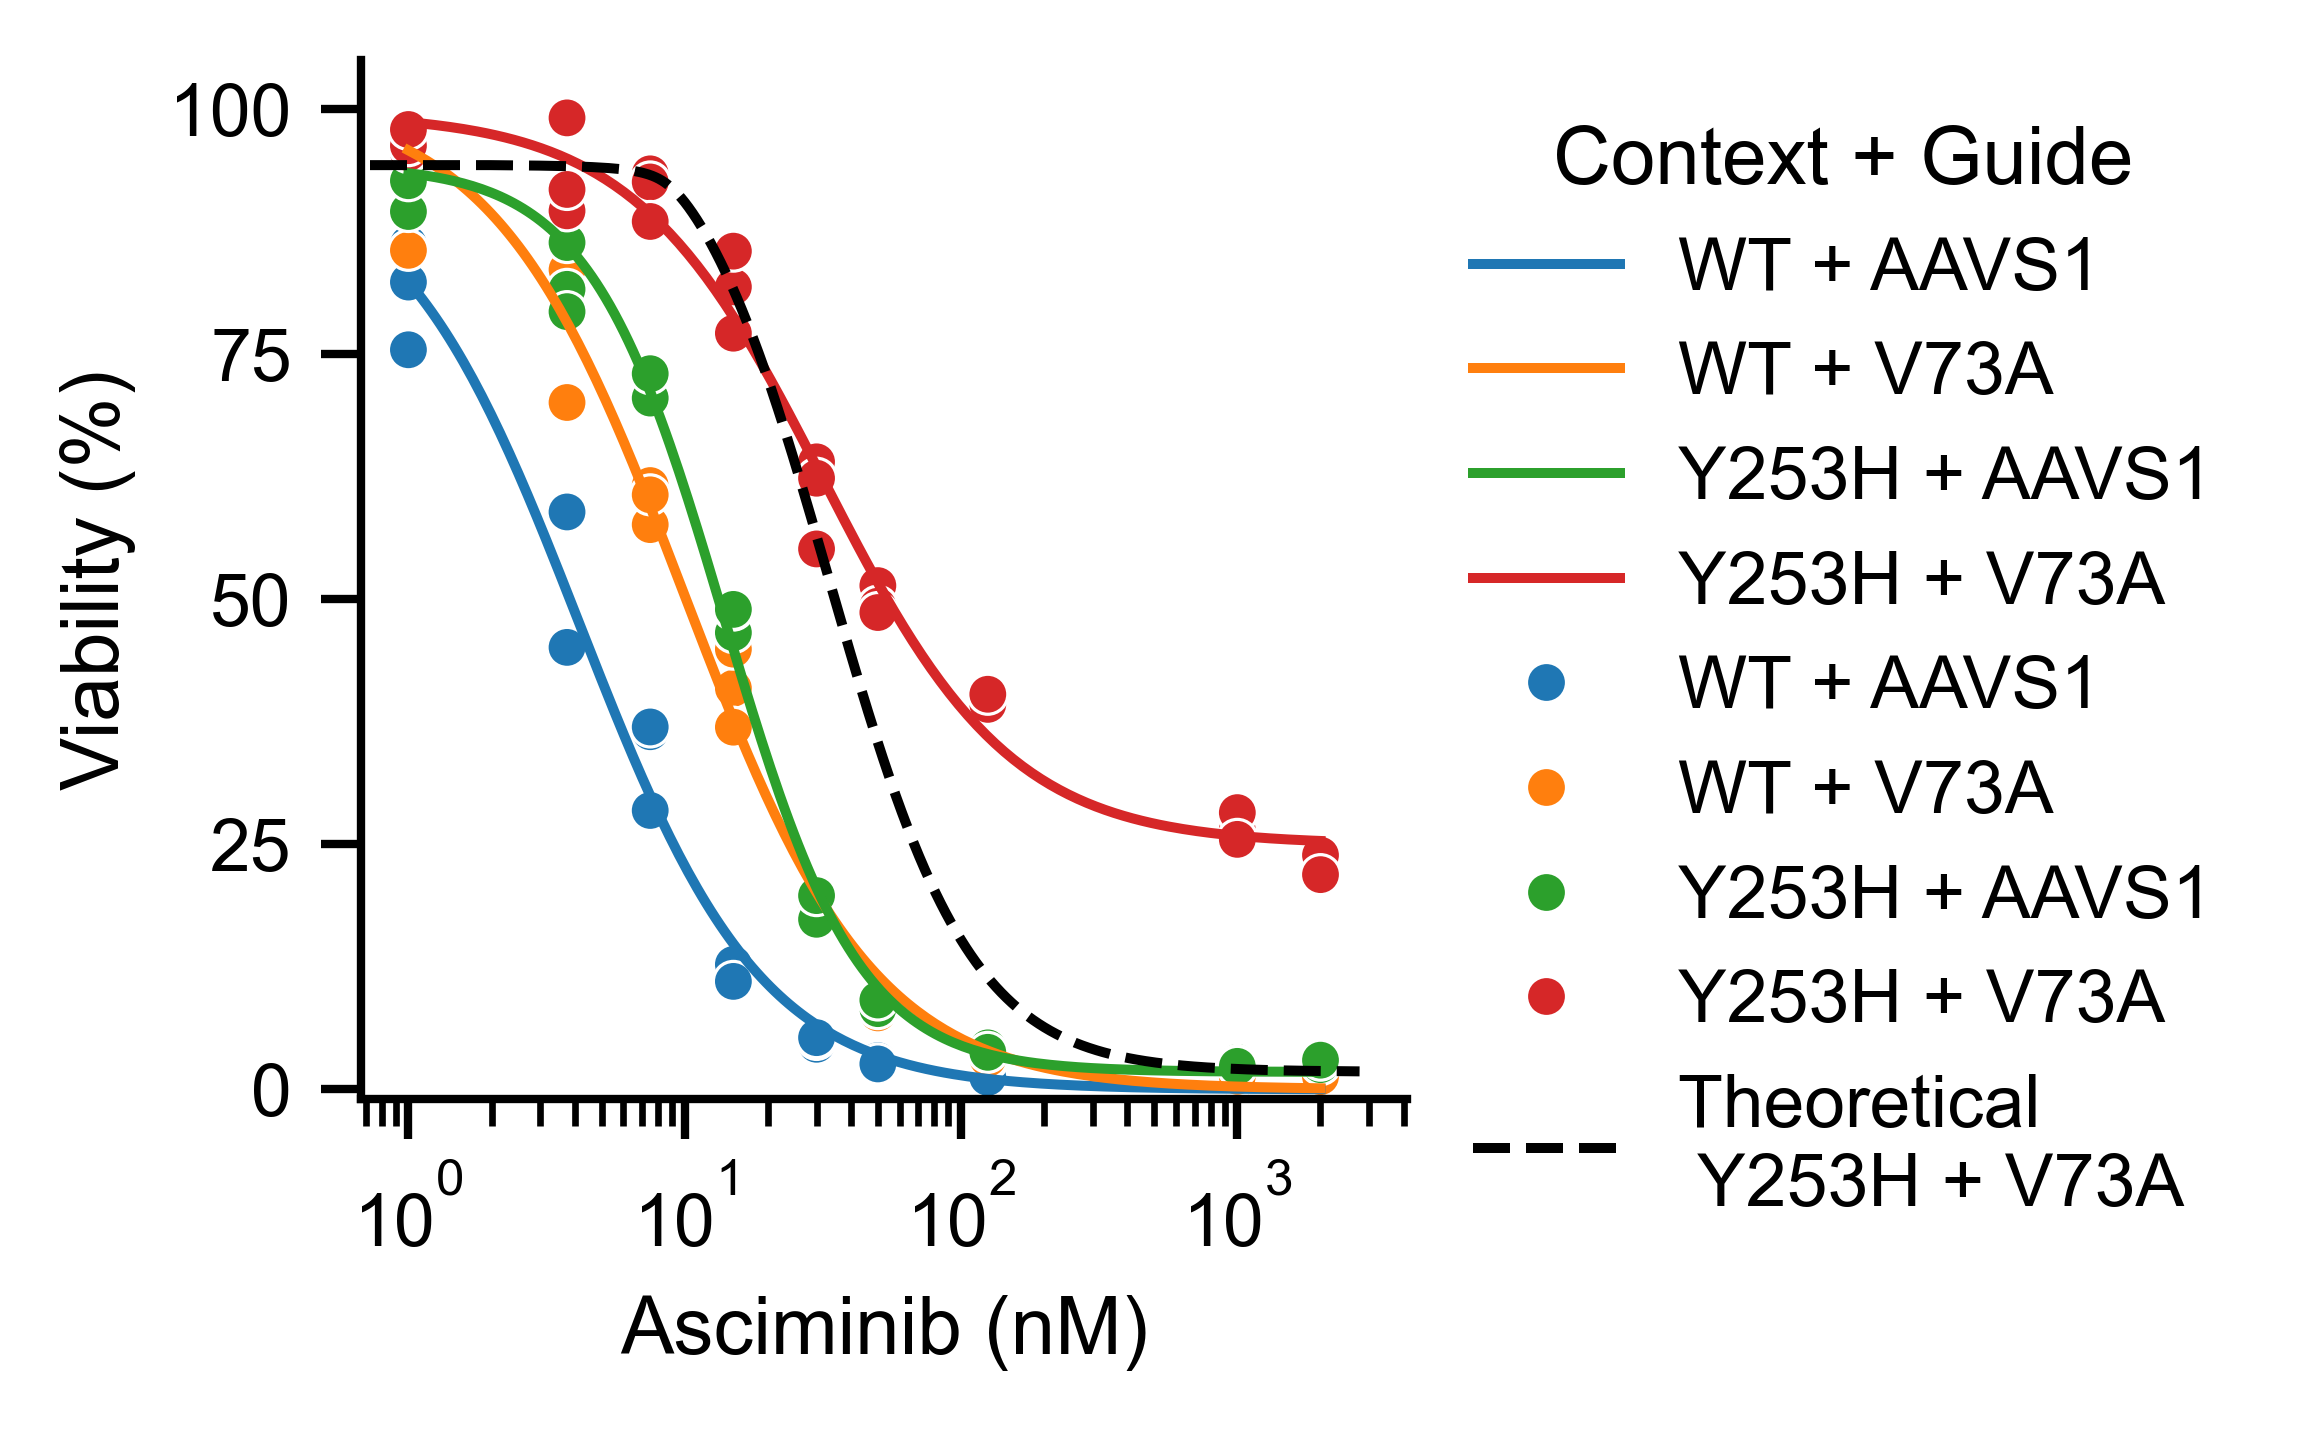

In [25]:
mpl.rcParams['figure.figsize'] = 2.25,2.25
drug_resp = sns.lineplot(x='Conc', y='Responce', hue='Context + Guide', data=Asc_fit)
drug_resp = sns.scatterplot(x='Conc', y='Norm', hue='Context + Guide', markers='o', data=Asc_data)
drug_resp = sns.lineplot(x=C_AB_exp, y=v_grid*100, color='black', linestyle='--', label='Theoretical \n Y253H + V73A')
drug_resp.set_yticks([0, 25, 50, 75, 100])
drug_resp.set(xscale="log", ylabel='Viability (%)', xlabel= 'Asciminib (nM)', ylim=[-1, 105])
drug_resp.legend( frameon=False, bbox_to_anchor=(1, 1), title='Context + Guide')
sns.despine()
drug_resp.get_figure().savefig("/home/ivan/Desktop/Epi Analysis/Epistatic Confirmation/K562 WT and Y253H V73A Edited DR260111.pdf" , dpi=1200,  transparent=True, bbox_inches='tight')

### Null Epistatic Calculation

In [45]:
pseudo_count = 1

WT_AAVS1_bot = parameter_DF.loc[(parameter_DF['Drug']=='asciminib') & (parameter_DF['Cell']=='WT') & (parameter_DF['sgRNA']=='AAVS1'), 'Bot'].values*100 + pseudo_count
Y253H_AAVS1_bot = parameter_DF.loc[(parameter_DF['Drug']=='asciminib') & (parameter_DF['Cell']=='Y253H') & (parameter_DF['sgRNA']=='AAVS1'), 'Bot'].values*100 + pseudo_count
WT_BCR2_1054_bot = parameter_DF.loc[(parameter_DF['Drug']=='asciminib') & (parameter_DF['Cell']=='WT') & (parameter_DF['sgRNA']=='BCR2_1054'), 'Bot'].values*100 + pseudo_count
Y253H_BCR2_1054_bot = parameter_DF.loc[(parameter_DF['Drug']=='asciminib') & (parameter_DF['Cell']=='Y253H') & (parameter_DF['sgRNA']=='BCR2_1054'), 'Bot'].values*100

Y253H_BCR2_1054_bot_null = (WT_BCR2_1054_bot * Y253H_AAVS1_bot) / WT_AAVS1_bot

In [46]:
Y253H_BCR2_1054_bot, Y253H_BCR2_1054_bot_null

(array([25.]), array([2.8]))

#### Error propogation

In [47]:
WT_AAVS1_bot_sd = var_DF.loc[(var_DF['Drug']=='asciminib') & (var_DF['Cell']=='WT') & (var_DF['sgRNA']=='AAVS1'), 'Bot'].values*100
Y253H_AAVS1_bot_sd = var_DF.loc[(var_DF['Drug']=='asciminib') & (var_DF['Cell']=='Y253H') & (var_DF['sgRNA']=='AAVS1'), 'Bot'].values*100
WT_BCR2_1054_bot_sd = var_DF.loc[(var_DF['Drug']=='asciminib') & (var_DF['Cell']=='WT') & (var_DF['sgRNA']=='BCR2_1054'), 'Bot'].values*100
Y253H_BCR2_1054_bot_sd = var_DF.loc[(var_DF['Drug']=='asciminib') & (var_DF['Cell']=='Y253H') & (var_DF['sgRNA']=='BCR2_1054'), 'Bot'].values*100

In [48]:
rel_error_sq = ((WT_BCR2_1054_bot_sd / (WT_BCR2_1054_bot))**2 +
                (Y253H_AAVS1_bot_sd / (Y253H_AAVS1_bot))**2 +
                (WT_AAVS1_bot_sd / (WT_AAVS1_bot))**2)

Y253H_BCR2_1054_bot_null_sd = Y253H_BCR2_1054_bot_null * np.sqrt(rel_error_sq)
Y253H_BCR2_1054_bot_null_sd

array([6.75499994])

In [49]:
[[WT_AAVS1_bot, WT_AAVS1_bot_sd,
  WT_BCR2_1054_bot, WT_BCR2_1054_bot_sd,
  Y253H_AAVS1_bot, Y253H_AAVS1_bot_sd,
  Y253H_BCR2_1054_bot, Y253H_BCR2_1054_bot_sd
 ]]

[[array([1.]),
  array([1.258]),
  array([1.]),
  array([1.971]),
  array([2.8]),
  array([1.663]),
  array([25.]),
  array([2.322])]]

In [50]:
parameter_DF.loc[(parameter_DF['Drug']=='asciminib') & (parameter_DF['Cell']=='Y253H') & (parameter_DF['sgRNA']=='AAVS1'), 'Bot'].values

array([0.018])

### Testing for a diffrence

Each dose-response condition consists of 27 observations (9 doses measured in triplicate). To account for the four-parameter sigmoidal model used to estimate the Bot parameter, the degrees of freedom are calculated as N−4, resulting in df=23.

In [51]:
# 1. Inputs (Replace with your actual variables)
bot_obs = Y253H_BCR2_1054_bot      # Observed double mutant Bot
se_obs = Y253H_BCR2_1054_bot_sd    # SE of the observed Bot fit
df_obs = 23                   # 27 points - 4 parameters

bot_theo = Y253H_BCR2_1054_bot_null      # Your calculated (A*B)/WT
se_theo = Y253H_BCR2_1054_bot_null_sd    # Your propagated error
# For simplicity, df_theo is 23 since A, B, and WT all had same N
df_theo = 23 

# 2. Calculate Welches T-statistic

from scipy.stats import ttest_ind_from_stats
ttest_ind_from_stats(bot_obs, se_obs, df_obs, bot_theo, se_theo, df_theo, equal_var=False)

Ttest_indResult(statistic=array([14.90525448]), pvalue=array([1.37549644e-14]))

In [52]:
[bot_obs, se_obs, df_obs, bot_theo, se_theo, df_theo]

[array([25.]), array([2.322]), 23, array([2.8]), array([6.75499994]), 23]

### Alternative method for error propogation is Monte Carlo Simulation with a truncated normal distribution at the limit of detection (1%)

In [254]:
def calculate_null_bot_with_error(A_mu, A_sd, B_mu, B_sd, C_mu, C_sd, n_samples=100000):
    # 1. Generate random samples for each parameter
    # We use max(0, ...) to ensure we don't get negative viability
    A_samples = np.maximum(1, np.random.normal(A_mu, A_sd, n_samples))
    B_samples = np.maximum(1, np.random.normal(B_mu, B_sd, n_samples))
    C_samples = np.maximum(1, np.random.normal(C_mu, C_sd, n_samples)) # Avoid 0 in denominator
    
    # 2. Calculate the null bot for every sample
    null_samples = (A_samples * B_samples) / C_samples
    
    # 3. Extract the stable mean and SD
    # We use the median or mean, and the standard deviation of the samples
    stable_mean = np.mean(null_samples)
    stable_sd = np.std(null_samples)
    
    return stable_mean, stable_sd

# Apply to your data
predicted_bot, predicted_bot_sd = calculate_null_bot_with_error(
    WT_BCR2_1054_bot, WT_BCR2_1054_bot_sd,
    Y253H_AAVS1_bot, Y253H_AAVS1_bot_sd,
    WT_AAVS1_bot, WT_AAVS1_bot_sd
)

In [255]:
predicted_bot, predicted_bot_sd 

(4.052311521368477, 3.967342126040511)